# Flat and two-layer LMDP walkthrough

This notebook follows the implementation from the physical maze to the exact flat solution and then the two-layer multitask model. All examples use the canonical parameters and fixed random seeds.

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from andrew_mlmdp import (
    Maze,
    ModelParameters,
    NMFDiscoveryParameters,
    animate_hierarchical_rollout,
    animate_soft_hierarchical_rollout,
    build_goal_task_ensemble,
    build_subgoal_passive_dynamics,
    build_soft_two_layer_model,
    build_two_layer_model,
    compute_layer_one_plan,
    controlled_dynamics,
    desirability_grid,
    evaluate_soft_subtask_ranks,
    factorize_soft_subtasks,
    paper_hierarchy_parameters,
    soft_hierarchy_parameters,
    plot_controlled_dynamics,
    plot_interactive_subgoal_desirability,
    plot_interactive_soft_hierarchical_rollout,
    plot_soft_subtask_rank_diagnostics,
    plot_soft_subtasks,
    plot_subgoal_passive_dynamics,
    plot_trajectory,
    sample_hierarchical_rollout,
    sample_online_hierarchical_rollout,
    sample_rollout,
    sample_soft_hierarchical_rollout,
    solve_desirability,
)

## Canonical configuration

These are project defaults rather than values uniquely fixed by the paper.

In [2]:
parameters = ModelParameters(upper_control_cost=.85, lower_control_cost=.1,off_target_reward=-1)
maze = Maze.from_file(PROJECT_ROOT / 'mazes' / 'four_rooms.txt')
goal = (10, 9)

print(parameters)
print(f'maze shape: {maze.shape}')
print(f'free states: {len(maze.free_cells)}')
print(f'goal state: {maze.state_index(goal)}')

ModelParameters(interior_reward=-0.1, goal_reward=1.1, lower_control_cost=0.1, upper_control_cost=0.85, alpha=0.2, off_target_reward=-1, beta=16.0)
maze shape: (11, 11)
free states: 97
goal state: 95


## Exact flat first-exit LMDP

`solve_desirability` constructs and solves Equation 4. The vector follows `maze.free_cells` order and includes the terminal goal value.

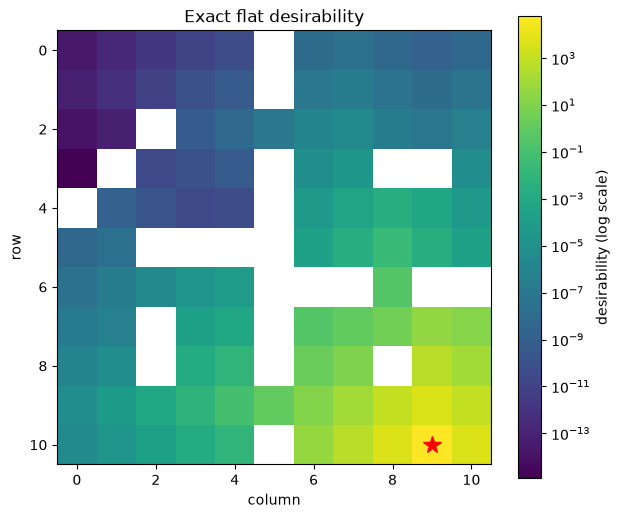

In [3]:
flat_desirability = solve_desirability(
    maze,
    goal,
    parameters=parameters,
)
flat_grid = desirability_grid(maze, flat_desirability)
positive = flat_grid[np.isfinite(flat_grid) & (flat_grid > 0.0)]

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(
    flat_grid,
    cmap='viridis',
    norm=LogNorm(vmin=positive.min(), vmax=positive.max()),
)
ax.plot(goal[1], goal[0], marker='*', color='red', markersize=13)
ax.set(title='Exact flat desirability', xlabel='column', ylabel='row')
fig.colorbar(image, ax=ax, label='desirability (log scale)')
plt.show()

### Controlled dynamics and a seeded rollout

Equation 6 reweights each passive next-state probability by the desirability of that next state.

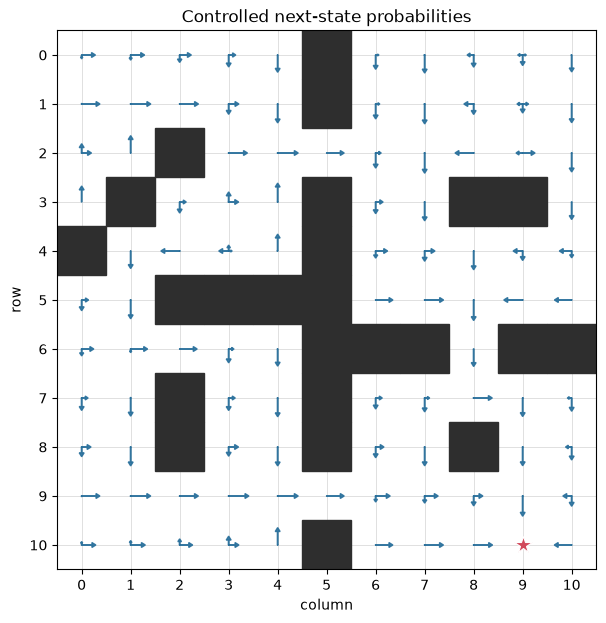

In [4]:
flat_controlled = controlled_dynamics(maze, flat_desirability)
plot_controlled_dynamics(maze, flat_controlled, goal=goal)
plt.show()

reached goal: True
physical steps: 27


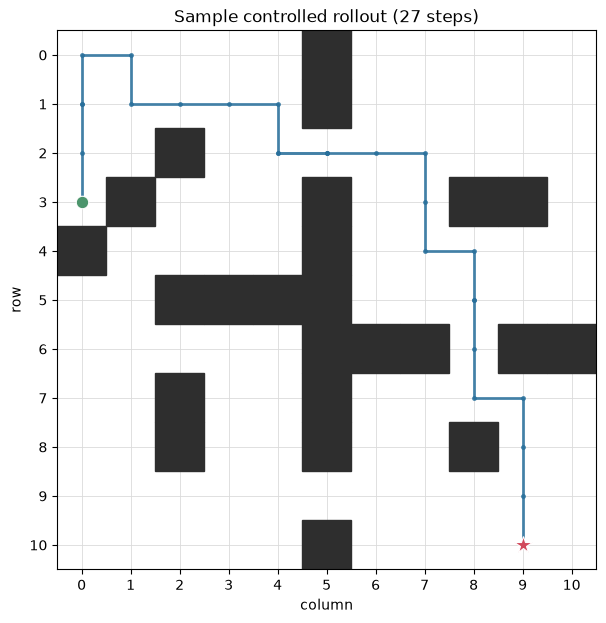

In [5]:
flat_start = (3,0)
flat_rollout = sample_rollout(
    maze,
    flat_controlled,
    start=flat_start,
    goal=goal,
    seed=0,
)

print(f'reached goal: {flat_rollout[-1] == goal}')
print(f'physical steps: {len(flat_rollout) - 1}')
plot_trajectory(maze, flat_rollout, goal=goal)
plt.show()

## Two-layer multitask LMDP

The lower layer adds abstract boundary copies at A-F. First-hit probabilities through those copies induce the upper passive dynamics from Equations 8 and 9.

In [ ]:
subgoal_labels = ('A', 'B', 'C', 'D', 'E', 'F')
subgoals = (
    (0, 0),
    (9, 2),
    (2, 3),
    (3, 7),
    (9, 7),
    (7, 9),
)
hierarchical_start = (3,2)

### Task-independent upper passive graph

This is the square subgoal graph used for the Figure 3a-style view, before a current physical goal is added.

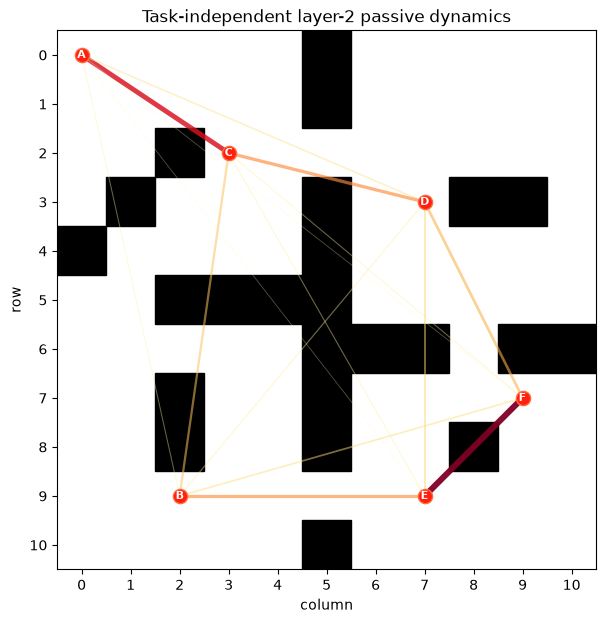

[[0.7541 0.0213 0.1663 0.0412 0.0086 0.0085]
 [0.0213 0.7311 0.0673 0.0282 0.104  0.0482]
 [0.1663 0.0673 0.6131 0.1055 0.0249 0.023 ]
 [0.0412 0.0282 0.1055 0.689  0.0543 0.0818]
 [0.0086 0.104  0.0249 0.0543 0.5984 0.2098]
 [0.0085 0.0482 0.023  0.0818 0.2098 0.6286]]


In [7]:
subgoal_passive = build_subgoal_passive_dynamics(
    maze,
    subgoals,
    parameters=parameters,
)
fig, ax = plt.subplots(figsize=(7, 7))
plot_subgoal_passive_dynamics(
    maze,
    subgoals,
    subgoal_passive,
    labels=subgoal_labels,
    ax=ax,
)
plt.show()
print(np.round(subgoal_passive, 4))

### Goal-conditioned model

The model groups its arrays by meaning: lower first-exit dynamics, the multitask basis, and upper first-exit dynamics.

In [8]:
model = build_two_layer_model(
    maze,
    subgoals,
    goal,
    parameters=parameters,
)

print('target order:', subgoal_labels + ('goal',))
print('lower passive:', model.lower_dynamics.passive.shape)
print('boundary basis Q_b:', model.task_basis.boundary_desirability.shape)
print('interior basis Z_i:', model.task_basis.interior_desirability.shape)
print('upper passive:', model.upper_dynamics.passive.shape)

target order: ('A', 'B', 'C', 'D', 'E', 'F', 'goal')
lower passive: (103, 96)
boundary basis Q_b: (7, 7)
interior basis Z_i: (96, 7)
upper passive: (7, 6)


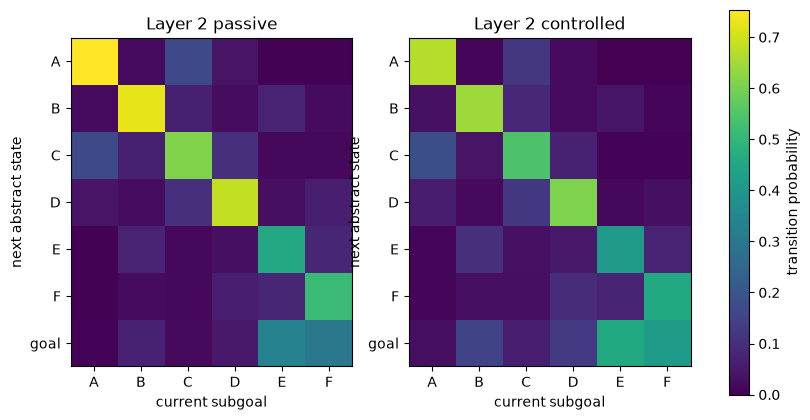

In [9]:
abstract_labels = subgoal_labels + ('goal',)
matrix_maximum = max(
    model.upper_dynamics.passive.max(),
    model.upper_controlled.max(),
)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, matrix, title in (
    (axes[0], model.upper_dynamics.passive, 'Layer 2 passive'),
    (axes[1], model.upper_controlled, 'Layer 2 controlled'),
):
    image = ax.imshow(
        matrix, cmap='viridis', vmin=0.0, vmax=matrix_maximum
    )
    ax.set_xticks(np.arange(len(subgoal_labels)), subgoal_labels)
    ax.set_yticks(np.arange(len(abstract_labels)), abstract_labels)
    ax.set(xlabel='current subgoal', ylabel='next abstract state', title=title)

fig.colorbar(image, ax=axes, label='transition probability')
plt.show()

### Reward inpainting and task composition

Equation 10 creates the subgoal reward signal. Equation 7 projects its exponentiated boundary values into the task basis.

In [10]:
initial_plan = compute_layer_one_plan(model, hierarchical_start)

print(' target   passive  controlled  reward    weight')
for label, passive, controlled, reward, weight in zip(
    abstract_labels,
    initial_plan.passive_abstract,
    initial_plan.controlled_abstract,
    initial_plan.inpainted_rewards,
    initial_plan.weights,
):
    print(
        f' {label:>4}    {passive:7.3f}     {controlled:7.3f}'
        f'    {reward:7.3f}   {weight:7.3f}'
    )

 target   passive  controlled  reward    weight
    A      0.754       0.670     -1.339     0.000
    B      0.021       0.033      0.199     0.000
    C      0.166       0.182      0.249     0.000
    D      0.041       0.058      0.282     0.000
    E      0.006       0.014      0.140     0.000
    F      0.006       0.015      0.141     0.000
 goal      0.007       0.028      1.100     1.000


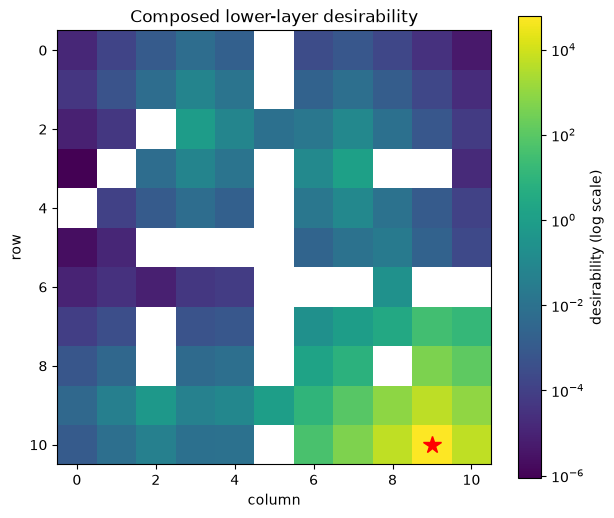

In [11]:
composed_grid = desirability_grid(
    maze, initial_plan.physical_desirability
)
positive = composed_grid[
    np.isfinite(composed_grid) & (composed_grid > 0.0)
]
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(
    composed_grid,
    cmap='viridis',
    norm=LogNorm(vmin=positive.min(), vmax=positive.max()),
)
ax.plot(goal[1], goal[0], marker='*', color='red', markersize=13)
ax.set(title='Composed lower-layer desirability', xlabel='column', ylabel='row')
fig.colorbar(image, ax=ax, label='desirability (log scale)')
plt.show()

### Seeded hierarchical rollout

Subgoal-copy accesses update the active task blend without consuming physical time.

status: reached_goal
physical steps: 25
zero-time accesses: [(2, 3), (3, 7), (7, 9)]


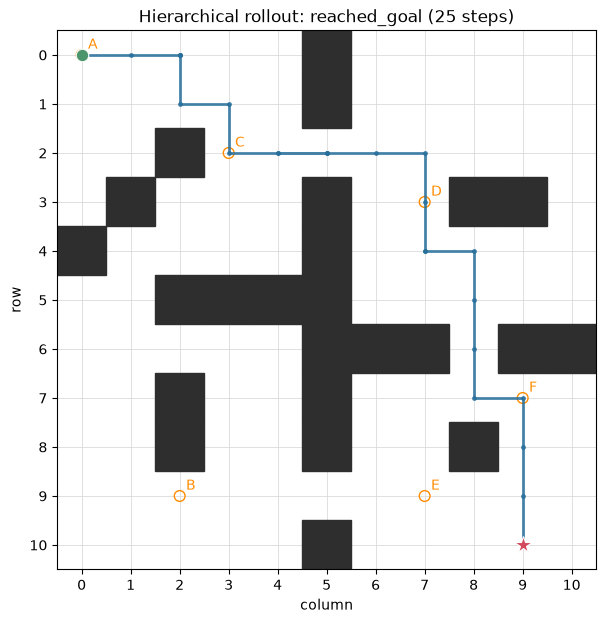

In [12]:
hierarchical_rollout = sample_hierarchical_rollout(
    model,
    hierarchical_start,
    seed=0,
)

print('status:', hierarchical_rollout.status)
print('physical steps:', hierarchical_rollout.physical_steps)
print('zero-time accesses:', hierarchical_rollout.subgoal_accesses)

ax = plot_trajectory(
    maze, hierarchical_rollout.trajectory, goal=goal
)
for label, (row, column) in zip(subgoal_labels, subgoals):
    ax.scatter(
        column, row, s=60, facecolors='none', edgecolors='darkorange'
    )
    ax.text(column + 0.13, row - 0.13, label, color='darkorange')
ax.set_title(
    f'Hierarchical rollout: {hierarchical_rollout.status} '
    f'({hierarchical_rollout.physical_steps} steps)'
)
plt.show()

### Animated hierarchical rollout

The dashboard pauses at each zero-time subgoal access to show the updated upper-layer policy and lower-layer desirability.

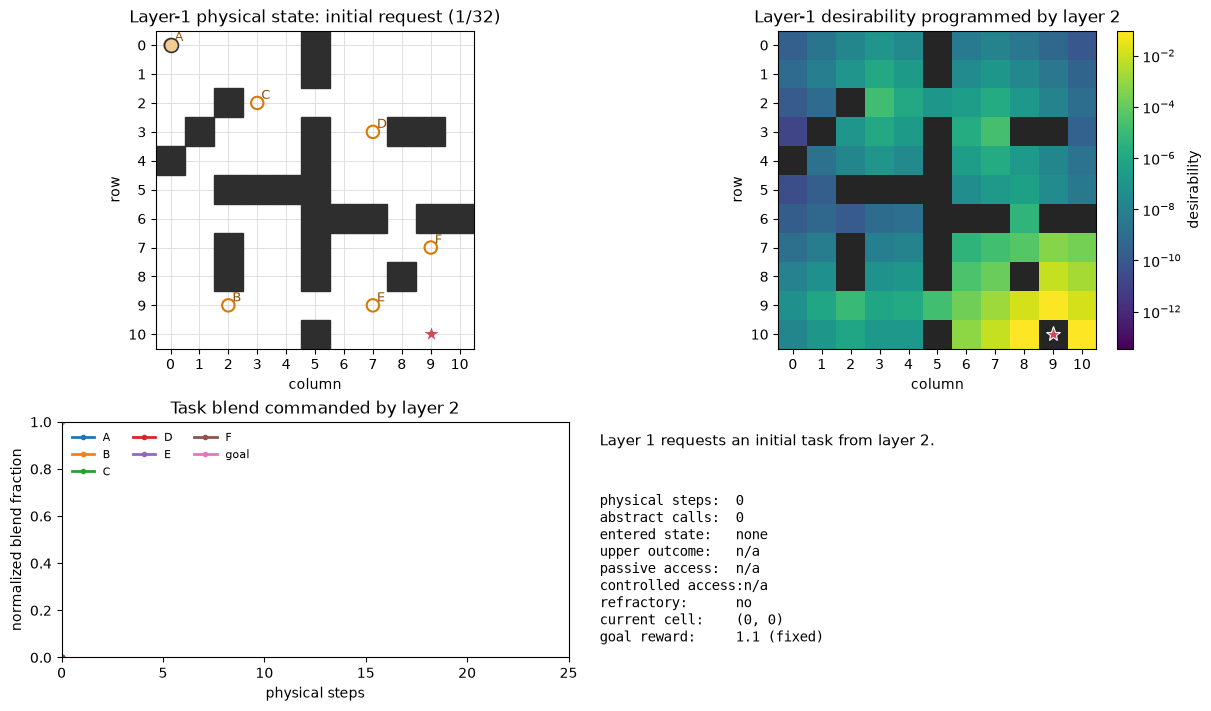

In [13]:
from IPython.display import HTML

rollout_animation = animate_hierarchical_rollout(
    model,
    hierarchical_start,
    seed=0,
    max_steps=100,
    interval=450,
    subgoal_labels=subgoal_labels,
)

HTML(rollout_animation.to_jshtml())

### Online goal Z-iteration

Here the reusable A-F basis and layer 2 remain exact, but the seventh physical-goal solution starts at zero and receives one full Equation 5 sweep after each nonterminal physical move.

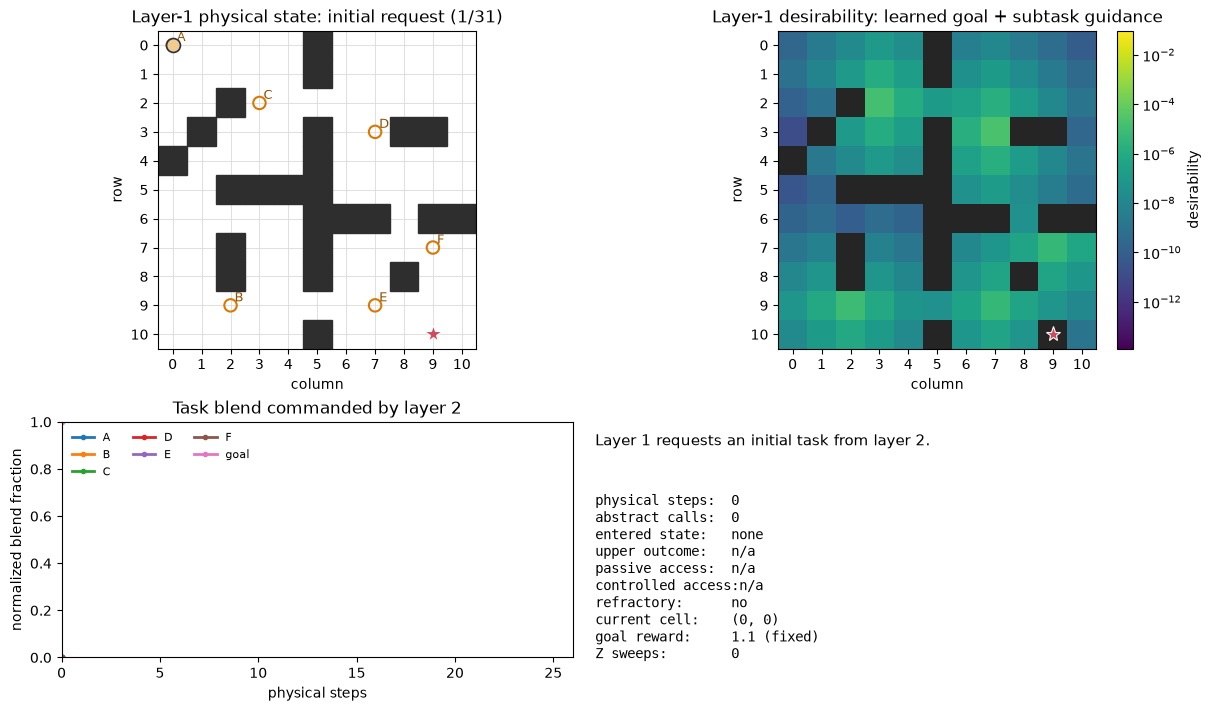

In [14]:
online_animation = animate_hierarchical_rollout(
    model,
    hierarchical_start,
    goal_learning='online',
    z_sweeps_per_step=1,
    max_steps=100,
    seed=28,
    interval=450,
    subgoal_labels=subgoal_labels,
)

HTML(online_animation.to_jshtml())

### Continue goal learning across episodes

Learning persistence is explicit: pass one episode's final goal vector into the next rollout.

In [15]:
learned_goal = None
online_episodes = []

for episode_seed in range(5):
    episode = sample_online_hierarchical_rollout(
        model,
        hierarchical_start,
        initial_goal_desirability=learned_goal,
        z_sweeps_per_step=1,
        max_steps=100,
        seed=episode_seed,
    )
    online_episodes.append(episode)
    learned_goal = episode.final_goal_desirability

for index, episode in enumerate(online_episodes, start=1):
    print(
        f'episode {index}: {episode.status}, '
        f'{episode.physical_steps} physical steps, '
        f'{episode.z_iterations} Z sweeps'
    )

episode 1: reached_goal, 25 physical steps, 24 Z sweeps
episode 2: reached_goal, 20 physical steps, 19 Z sweeps
episode 3: reached_goal, 20 physical steps, 19 Z sweeps
episode 4: reached_goal, 24 physical steps, 23 Z sweeps
episode 5: reached_goal, 23 physical steps, 22 Z sweeps


### Interactive subgoal composition

Drag the agent and goal markers around the maze to inspect the goal-conditioned A-F task blend. The interior heatmap excludes the seventh physical-goal basis contribution while retaining the fixed goal boundary value.

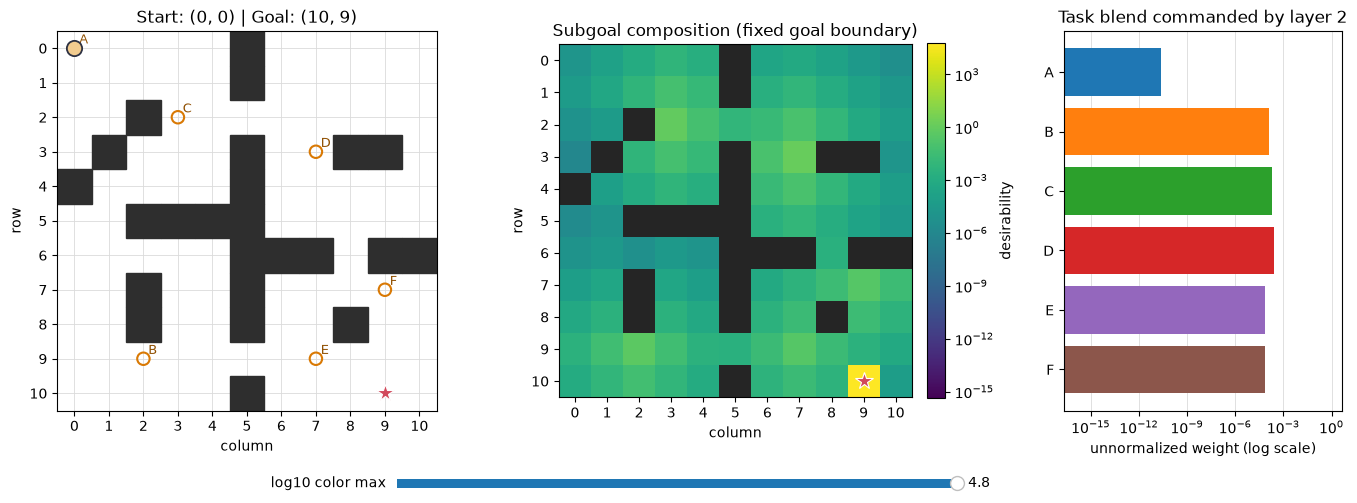

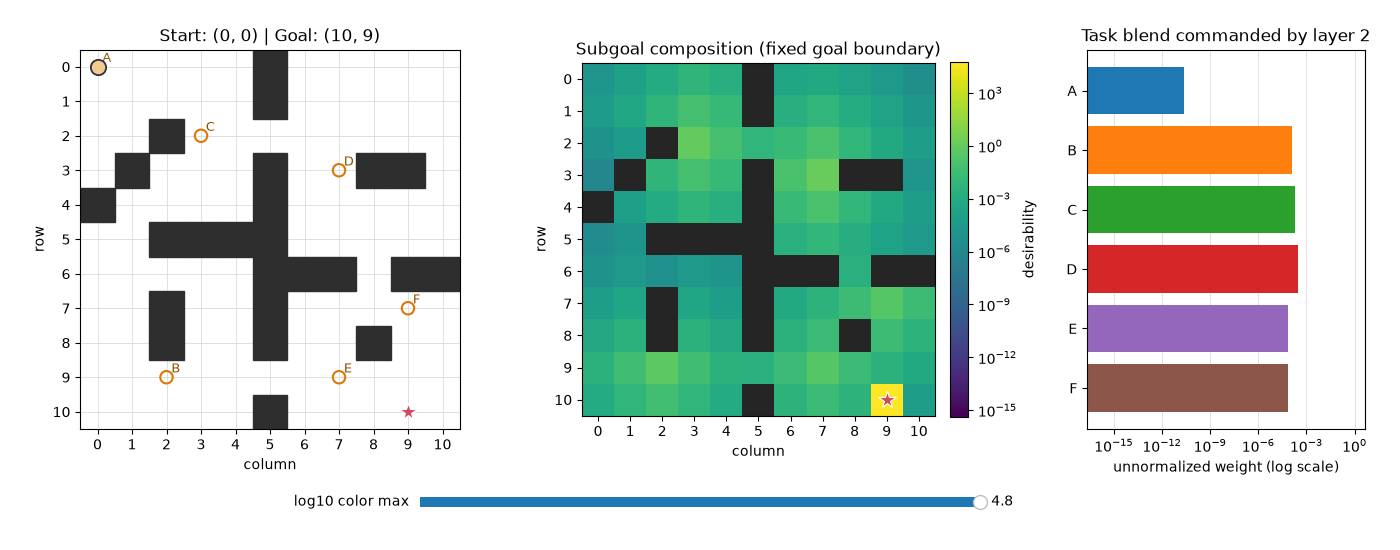

In [16]:
%matplotlib widget

interactive_figure = plot_interactive_subgoal_desirability(
    model,
    hierarchical_start,
    subgoal_labels=subgoal_labels,
)
interactive_figure

## NMF-discovered soft subtasks

Following Earle, Saxe, and Rosman (2017), solve one task per free-cell goal and factor the resulting desirability ensemble as $Z \approx D W$. Each max-normalized column of $D$ becomes a distributed access profile rather than a single subgoal square.

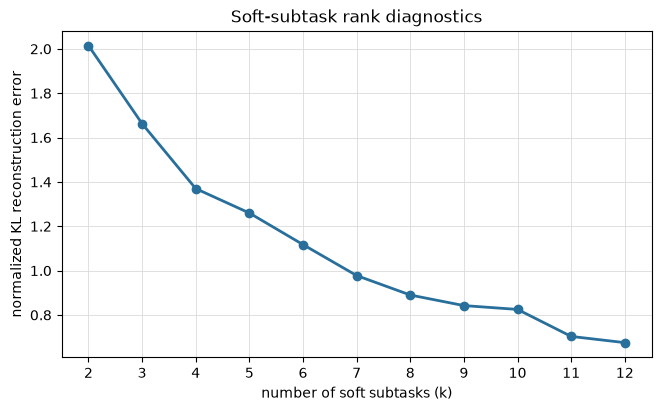

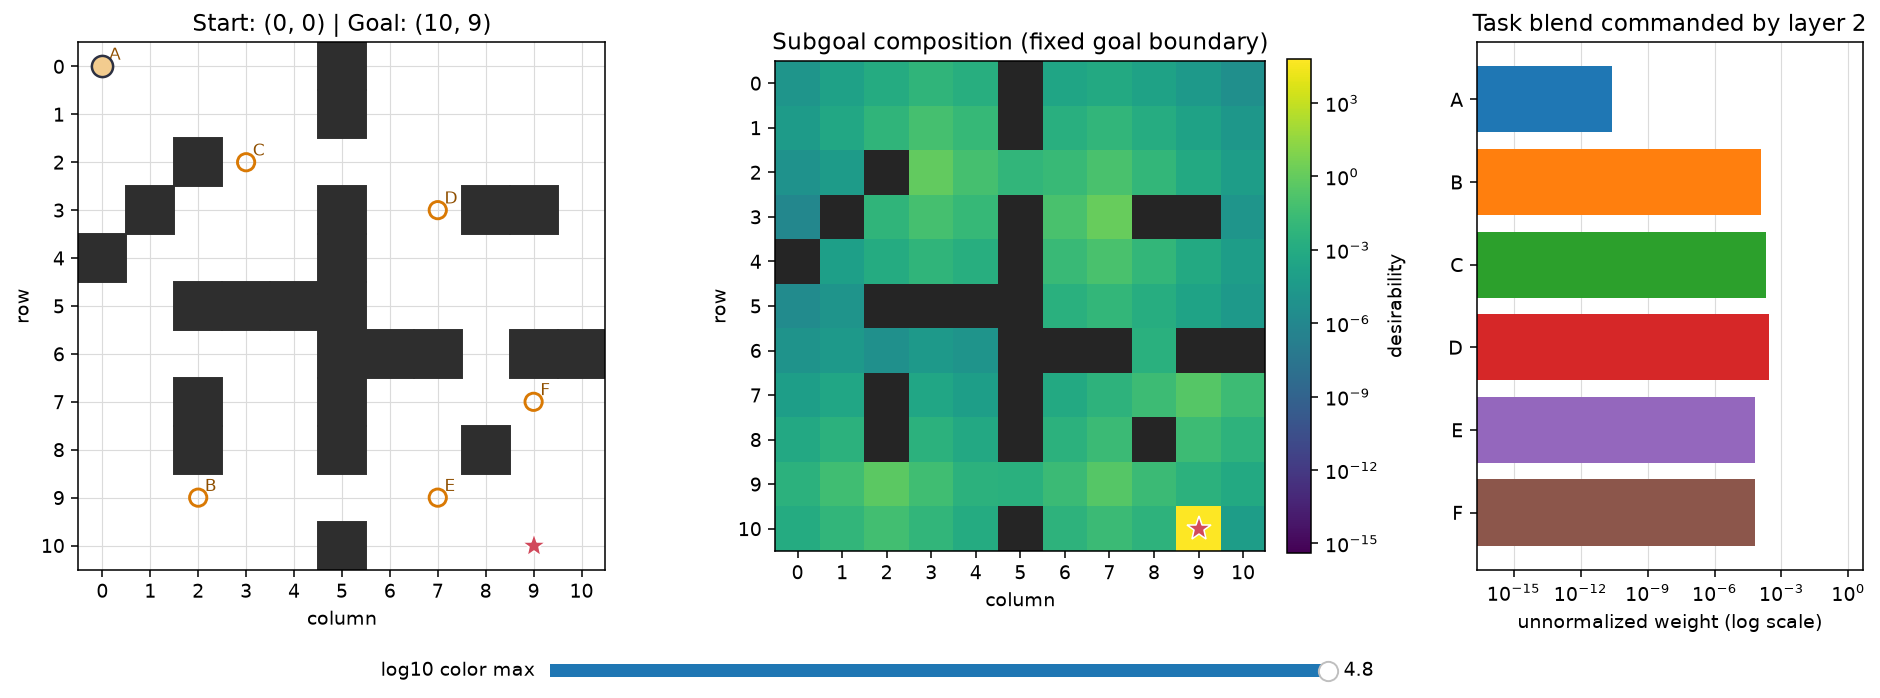

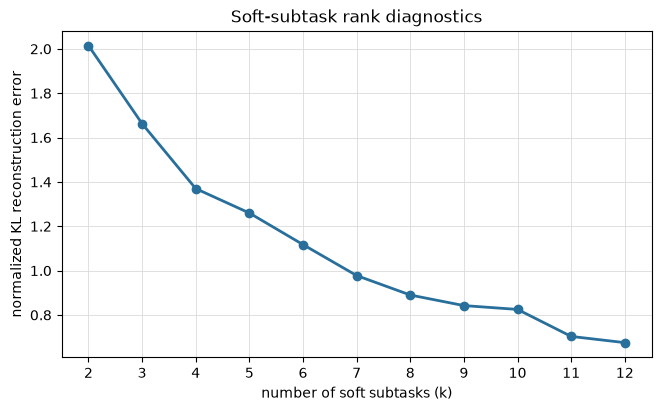

In [17]:
%matplotlib inline

soft_discovery_parameters = NMFDiscoveryParameters()
soft_execution_parameters = soft_hierarchy_parameters(k=8)

soft_ensemble = build_goal_task_ensemble(
    maze,
    discovery_parameters=soft_discovery_parameters,
)
soft_rank_diagnostics = evaluate_soft_subtask_ranks(
    soft_ensemble,
    ranks=tuple(range(2, 13)),
)
plot_soft_subtask_rank_diagnostics(soft_rank_diagnostics)

normalized KL error: 0.890; 80 iterations; converged=True


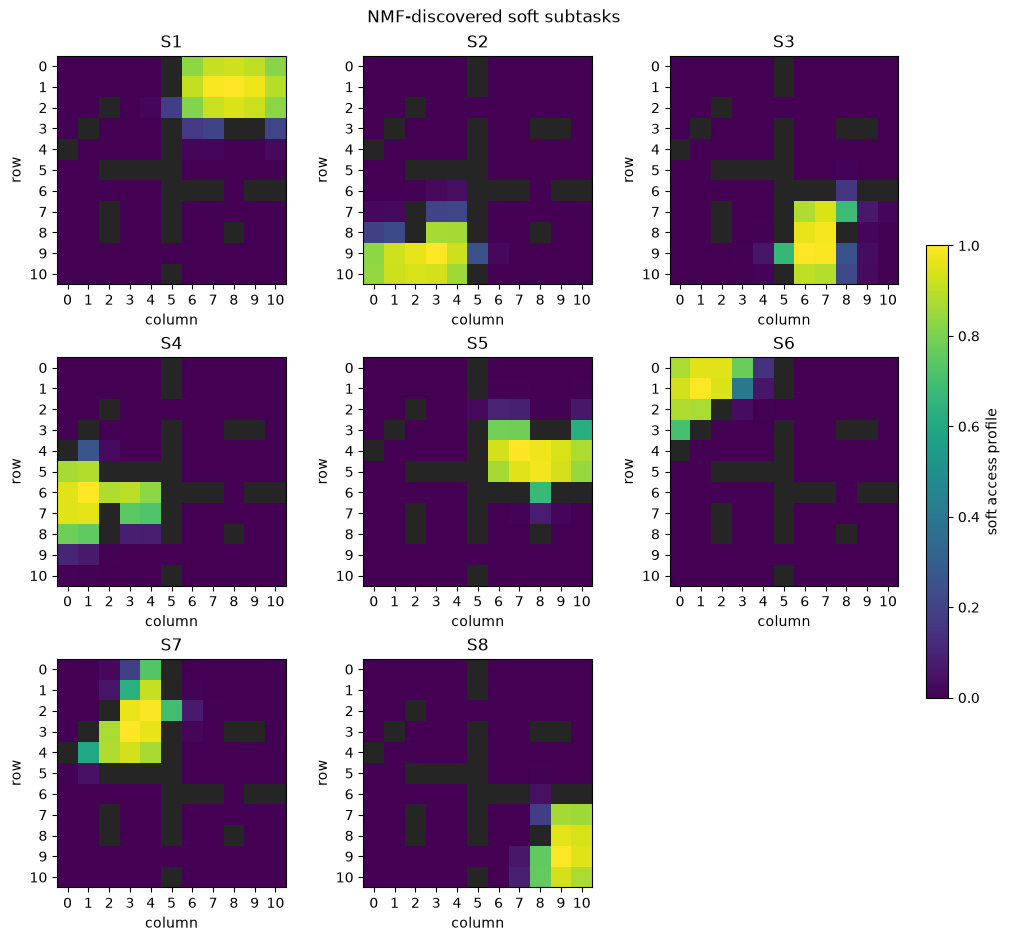

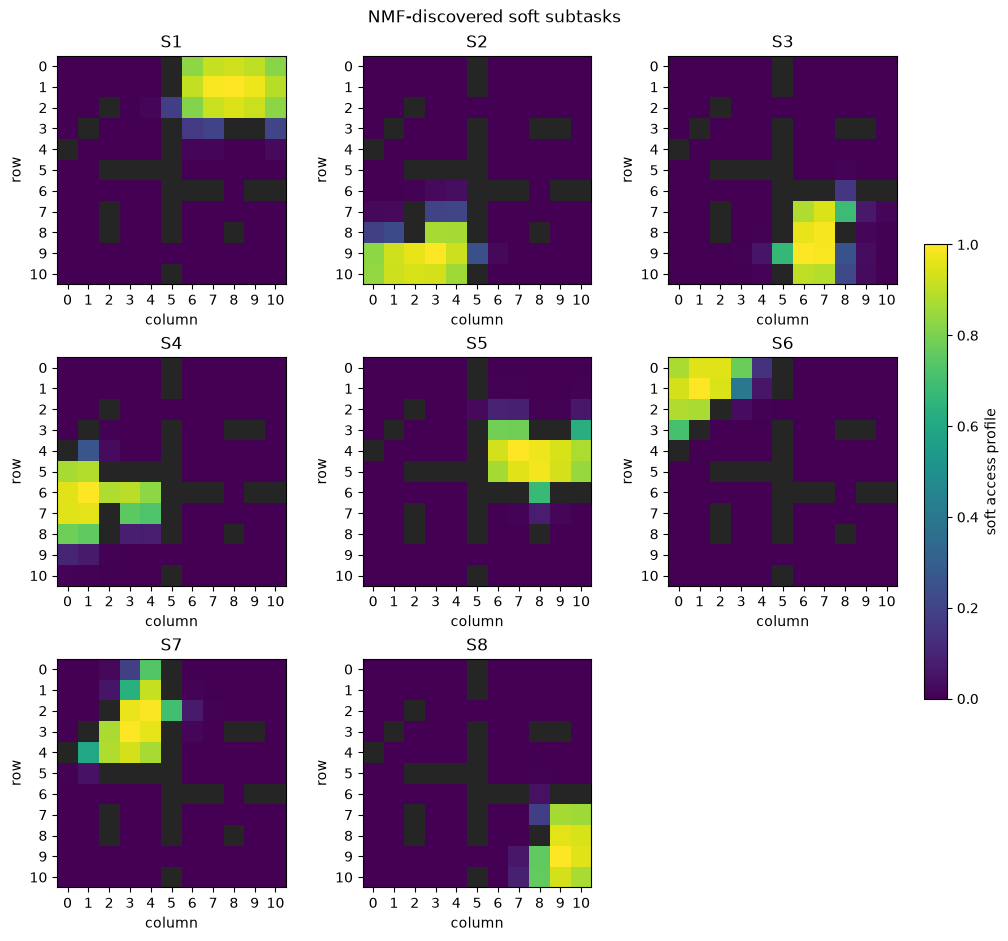

In [18]:
soft_discovery = factorize_soft_subtasks(
    soft_ensemble,
    n_subtasks=8,
)
print(
    f'normalized KL error: {soft_discovery.reconstruction_error:.3f}; '
    f'{soft_discovery.n_iter} iterations; '
    f'converged={soft_discovery.converged}'
)
plot_soft_subtasks(soft_discovery)

### Soft-subtask rollout

Broad profiles can be accessed from many cells, so this example uses a smaller $\alpha$ than the point-subgoal model. A soft access calls layer 2 at the agent's current physical cell; it never teleports the agent.

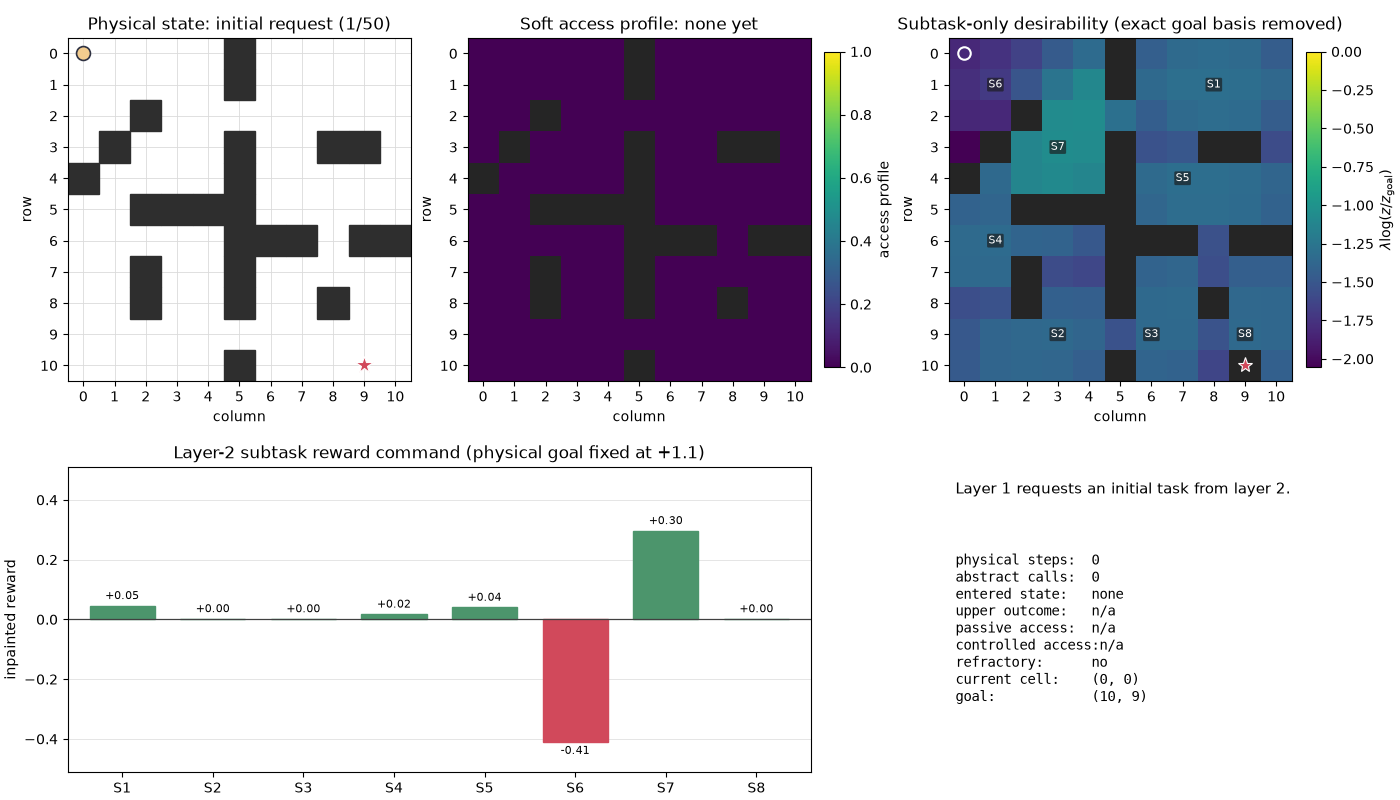

In [19]:
%matplotlib widget

from IPython.display import display

if "soft_animation" in globals():
    plt.close(soft_animation._fig)
if "soft_player" in globals():
    plt.close(soft_player.figure)

soft_model = build_soft_two_layer_model(
    maze,
    soft_discovery.profiles,
    goal,
    parameters=soft_execution_parameters,
    include_goal_component_while_active=False,
)
soft_player = plot_interactive_soft_hierarchical_rollout(
    soft_model,
    hierarchical_start,
    max_steps=100,
    max_abstract_accesses=100,
)
display(soft_player.controls)
plt.show()